# 5. Analysis of $\gamma$ Doradus stars

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import binned_statistic
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
star = 'GDOR'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'
path = f'/lhome/nicholas/software/workdir/mocka/simulations/analysis/{star}'
patha = f'{path}/finals_affogato'
pathc = f'{path}/finals_cortado'
pathd = f'{path}/finals_doppio'
pathv = f'{path}/varsource'

---
## Test to compare input and output
---

In [32]:
# Fetch simulation table
idir = patha
starID = f'{400}'.zfill(9)

# Fetch final ligth curve
lc = LightCurve(f'{idir}/final/lc_{starID}.ftr', mode="final")
df = lc.data()

# Load sim table
dt = pd.read_feather(f'{idir}/table/table_{starID}.ftr')

# Create varsource from pulsations
dx = pd.read_feather(f'{pathv}/pulsations/pulsations_{starID}_001.ftr')
dv = pd.DataFrame()
dv['time'] = df.time / 86400
dv['dmag'] = ns.timeSeriesFromFourier(dv.time, dx.freq, dx.ampl, dx.phase, power=2.2)
dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e6

#------------------

# Load star results
dm = pd.read_feather(f'{patha}/modes/modes_{starID}.ftr')
dp = pd.read_feather(f'{pathv}/parameters/parameters_{starID}_001.ftr')
df = pd.read_feather(f'{pathv}/pulsations/pulsations_{starID}_001.ftr')
# dp = pd.read_feather(f'{pathv}/parameters/{starID}_parameters.ftr')
# df = pd.read_feather(f'{pathv}/pulsations/{starID}_pulsations.ftr')

# Correct for gamma factor
df.ampl /= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = df0.freq.to_numpy() - dm0.freq.to_numpy()
A_oc = df0.ampl.to_numpy() - dm0.ampl.to_numpy()
dm1 = dm[dm.passed_snr]

# Remove matches above 0.01 c/d in the OC diagram
# x = 0.0005
x = 0.005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')
print(df.ampl.max())

Stellar magnitude  : 10.9002 mag
Limiting amplitude : 4.7747 ppm
Number of modes    : 10/13
RMS O-C amplitude  : 2.6313 ppm
RMS O-C frequency  : 50.9507 ppm/d
73.02637693984425


<IPython.core.display.Javascript object>


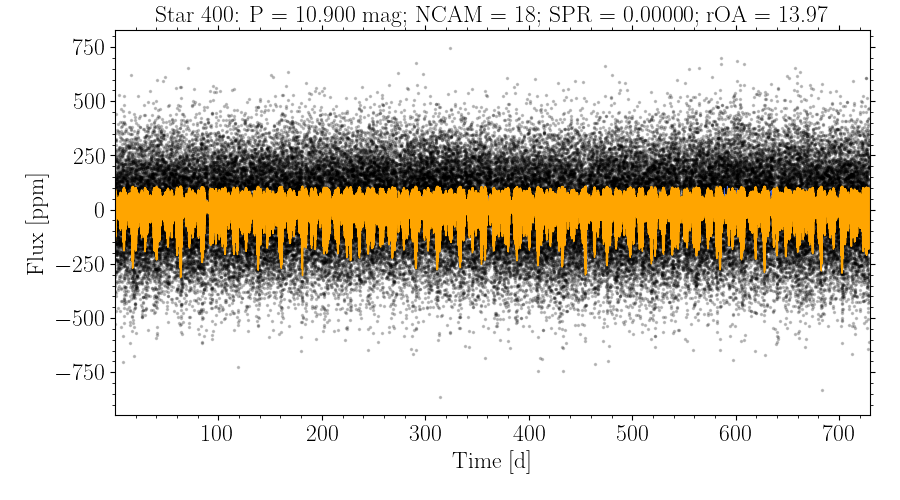

<IPython.core.display.Javascript object>


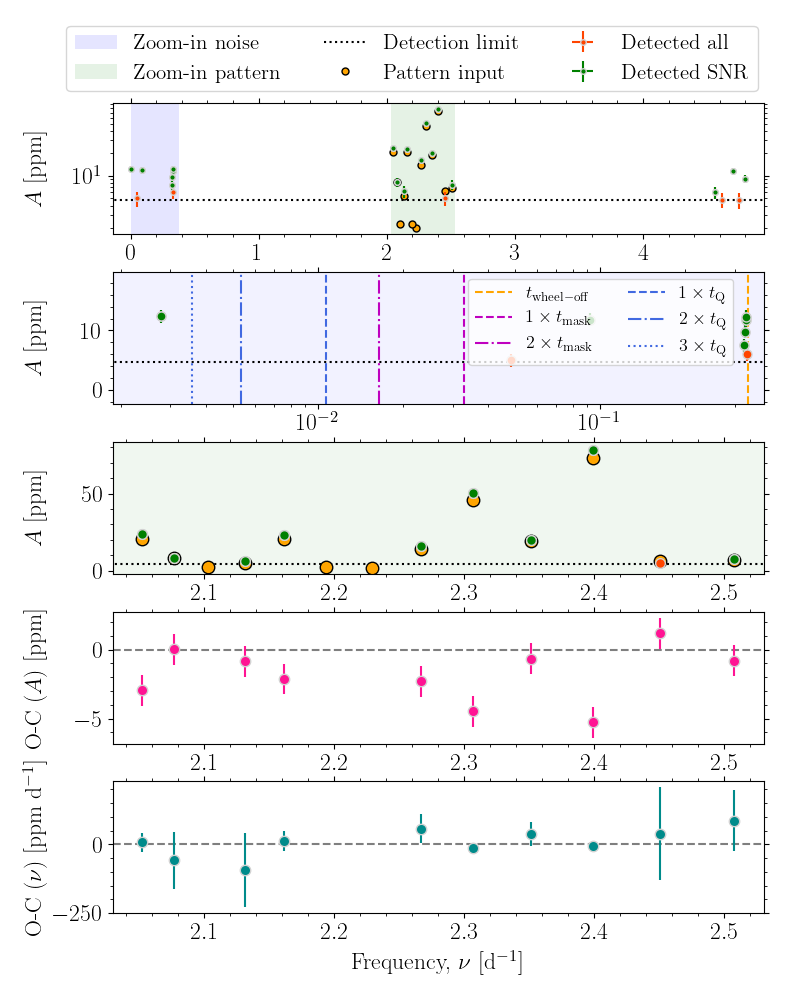

In [33]:
# PLOT FINAL LIGHT CURVE
fig, ax = lc.plot(flux_unit='ppm', median_filter=True, legend=False)
ax.plot(dv.time, dv.flux, '-', c='orange', lw=1)
ax.set_title(f'Star {int(starID)}: P = {dt.mag[0]:.3f} mag; NCAM = {int(dt.shape[0]/8)}; ' + 
             f'SPR = {dt.SPR.mean():.5f}; rOA = {dt.rOA.mean():.2f}')


# EXAMPLE PLOT OF MODE EXTRACTION
fig, ax = plt.subplots(5, 1, figsize=(8,10))

# Full range
xmin = np.min([df0.freq.min(), dm.freq.min()])
xmax = np.max([df0.freq.max(), dm.freq.max()])
xlim0 = pt.getAxesMinMax(x=[xmin, xmax], percentage=3)

# Zoom-in one systematics
dm_sys = dm.loc[:2] #[~(dm.freq == dm0.freq)]
xlim1 = (0, 0.38) #pt.getAxesMinMax(x=dm_sys.freq.to_numpy(), percentage=10)
ylim1 = pt.getAxesMinMax(y=dm_sys.ampl.to_numpy(), percentage=100)

# Zoom-in on mode pattern
xlim2 = pt.getAxesMinMax(x=df.freq.to_numpy(), percentage=5)[::-1]
ylim2 = pt.getAxesMinMax(x=df.ampl.to_numpy(), percentage=5)

# Plot all modes detected
ax[0].axvspan(0,        xlim1[1], color='b', alpha=0.1, lw=0, label='Zoom-in noise')
ax[0].axvspan(xlim2[0], xlim2[1], color='g', alpha=0.1, lw=0, label='Zoom-in pattern')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit') 
ax[0].plot(df0.freq, df0.ampl, 'o', ms=5, c='orange', mec='k', label='Pattern input')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, 
               mec='lightgray', color="orangered",  label='Detected all')
ax[0].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=8, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[0].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[0].legend([handles[i] for i in order], [labels[i] for i in order], 
             loc='upper center', ncol=3, bbox_to_anchor=(0.46, 1.66), fontsize=15.2)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

# Zoom-in on noise
ax[1].axvspan(xlim1[0], xlim1[1], color='b', alpha=0.05, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k')
ax[1].axvline(x=1/3,                    ls='--', c='orange',    label=r'$t_{\rm wheel-off}$')
ax[1].axvline(x=1/(ut.quarter()/3),     ls='--', c='m',     label=r'$1 \times t_{\rm mask}$')
ax[1].axvline(x=1/(ut.quarter()/3*2),   ls='-.', c='m',     label=r'$2 \times t_{\rm mask}$')
ax[1].axvline(x=1/(1*(ut.quarter()+2)), ls='--', c='royalblue', label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/(2*(ut.quarter()+2)), ls='-.', c='royalblue', label=r'$2 \times t_{\rm Q}$')
ax[1].axvline(x=1/(3*(ut.quarter()+2)), ls=':',  c='royalblue', label=r'$3 \times t_{\rm Q}$')
ax[1].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err,  fmt=".", ms=13, 
               mec='lightgray', color="orangered",  label='Detected all')
ax[1].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=13, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[1].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[1].legend([handles[i] for i in order], [labels[i] for i in order],
             loc='upper center', ncol=2, bbox_to_anchor=(0.75, 1.02), fontsize=13)
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_xscale('log')
ax[1].set_xlim(xlim1)
ax[1].set_ylim(ylim1)

# Zoom-in of pattern
ax[2].axvspan(xlim2[0], xlim2[1], color='g', alpha=0.06, lw=0)
ax[2].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[2].plot(df0.freq, df0.ampl, 'o', ms=9, c='orange', mec='k')
ax[2].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="orangered")
ax[2].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="green")
ax[2].set_ylabel(r'$A$ [ppm]')
# ax[2].set_yscale('log')
ax[2].set_xlim(xlim2)

# OC diagram for amplitudes
ax[3].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, 
               mec='lightgray', color="deeppink")
ax[3].set_ylabel(r'O-C ($A$) [ppm]')
ax[3].set_xlim(xlim2)

# OC diagram for frequencies
ax[4].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[4].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, 
               mec='lightgray', color="darkcyan")
ax[4].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[4].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[4].set_xlim(xlim2)

# Settings
for i in range(5): ax[i].get_yaxis().set_label_coords(-0.10, 0.5)
plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison.png', bbox_inches='tight', dpi=200)

In [6]:
df = lc.data()
(df - 1) * 1e6

,time,flux,flux_err
0,3.715004e+08,448.244525,-999733.863144
1,1.091501e+09,276.473991,-999733.894731
2,1.811502e+09,21.810279,-999734.022399
3,2.531503e+09,494.090001,-999734.100016
4,3.251504e+09,294.437765,-999734.186229
...,...,...,...
86699,6.302420e+13,275.816400,-999723.352514
86700,6.302492e+13,431.974766,-999723.495936
86701,6.302564e+13,-49.501752,-999723.638326
86702,6.302636e+13,654.148221,-999723.784228


In [7]:
# Prepare for period-spacing pattern example
df = lc.data()
time = df.time / 86400
flux = (df.flux - 1) * 1e4
from platosim.noise import DFTpower
fn = 5
df = np.diff(time)[0] * 0.1
freq0, ampl0 = DFTpower(time, flux, f0=0, fn=fn, df=df)
per = 1 / df0.freq.to_numpy()
# per = df0.freq.to_numpy()

<IPython.core.display.Javascript object>


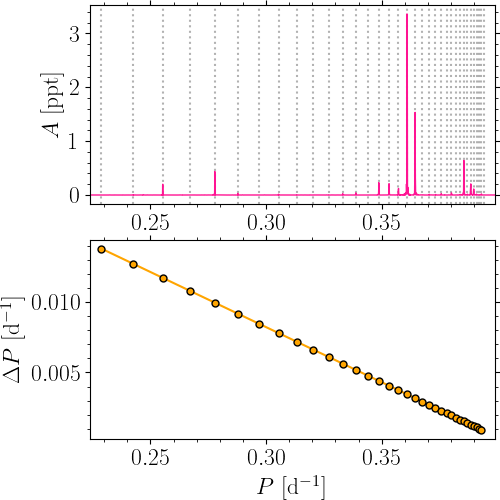

In [8]:
fig, ax = plt.subplots(2,1, figsize=(5,5))
for i in range(len(per)):
    ax[0].axvline(x=per[i], ymin=0, ymax=ampl0.max(), ls=':', c='k', alpha=0.3)
ax[0].plot(1/freq0, ampl0, '-', c='deeppink', lw=1, label='DFT')
ax[1].plot(per[:-1], np.diff(per), 'o-', ms=5, c='orange', mec='k', label='Pattern input')
for i in range(2):
    ax[i].set_xlim(per[0]-0.005, per[-1]+0.005)
# ax[0].set_yscale('log')
ax[0].set_ylabel('$A$ [ppt]')
ax[1].set_xlabel('$P$ [d$^{-1}$]')
ax[1].set_ylabel('$\Delta P$ [d$^{-1}$]')
plt.tight_layout(pad=0)
fig.savefig(f'{fdir}/talk/GDOR_Affogato_{starID}_period_spacing_pattern.png', bbox_inches='tight', dpi=200)

In [9]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

---
## Distribution of input modes
---

In [10]:
# Units: freq [], ampl []
filenames_all = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020_pattern/*')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
n_off = np.zeros(N)
df = pd.DataFrame()
da = pd.DataFrame()

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1':
            
            # Here missing modes are included as 9999.
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove mising modes and store periods
            df_i = dv_i[~(dv_i.per == 9999.0)]  
            
            # Number of modes (including missing ones)
            N_mod[i] = df_i.shape[0]
            
            # First period in pattern [days]
            P0[i] = df_i.per.iloc[0]
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
            
            # Lastly fetch amplitudes by matching to all freqs
            f0 = Path(filenames_all[0])
            f1 = f0.parent / (Path(s).stem[:12] + 'very_deep_clean.dat')
            dx_i = pd.read_csv(f1, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
            dex = []
            for p in df_i.per:
                dex.append(ut.findNearestIndex(dx_i.per, p))
            dx_i = dx_i.loc[dex].reset_index()
            
            # Maximum amplitude
            A_max[i] = dx_i.amp.max()
            
            # Store amplitudes
            df = pd.concat([df, df_i]) 
            da = pd.concat([da, dx_i])
                        
#---------- Test a single star -----------
#             n_off[i] = dx_i.amp.idxmax() / dx_i.shape[0] #/ dx_i.shape[0]       
#     if i == 20:
#         break
#-----------------------------------------

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)
P_kde     = scipy.stats.gaussian_kde(df.per)

# Fit log-norm function to mode amplitudes
grid = 10000
A_max = A_max  * 1e3
A_mag = da.amp * 1e3
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
param_mag = scipy.stats.lognorm.fit(A_mag)
A_lognorm = scipy.stats.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  
                                    scale=param_mag[2]) + 5e-5

100%|█████████████████████████████████████████████████▉| 608/609 [00:03<00:00, 185.98it/s]           


In [11]:
# LOAD SIMULATIONS
folders_parameters = natsort.natsorted(glob.glob(f'{pathv}/parameters/*'))
folders_pulsations = natsort.natsorted(glob.glob(f'{pathv}/pulsations/*'))

# Load all pulsation modes
N = len(folders_parameters)
N_modes = np.zeros(N)
PC = np.zeros(N)
df = pd.DataFrame()
for m,i,j in zip(range(N), folders_parameters, tqdm(folders_pulsations, bar_format=ut.tqdmBar())):    
    
    # Parameter file
    df_parameters = pd.read_feather(i)
    n = int(df_parameters.N_modes)
    N_modes[m] = n
#     print(df_parameters)
    PC[m] = df_parameters.PC_kepler
    
    # Pulsation file
    df_pulsations = pd.read_feather(j)
    df_pulsations['A_PC'] = df_pulsations.ampl / PC[m]

    # Save only pulsation modes
    df = pd.concat([df, df_pulsations[:n]])
    
# A_mag = dm.ampl * 1e3
A_sim = df.ampl * 1e3
A_PC  = df.A_PC * 1e3

100%|█████████████████████████████████████████████████▉| 3999/4000 [00:14<00:00, 269.60it/s]         


<IPython.core.display.Javascript object>


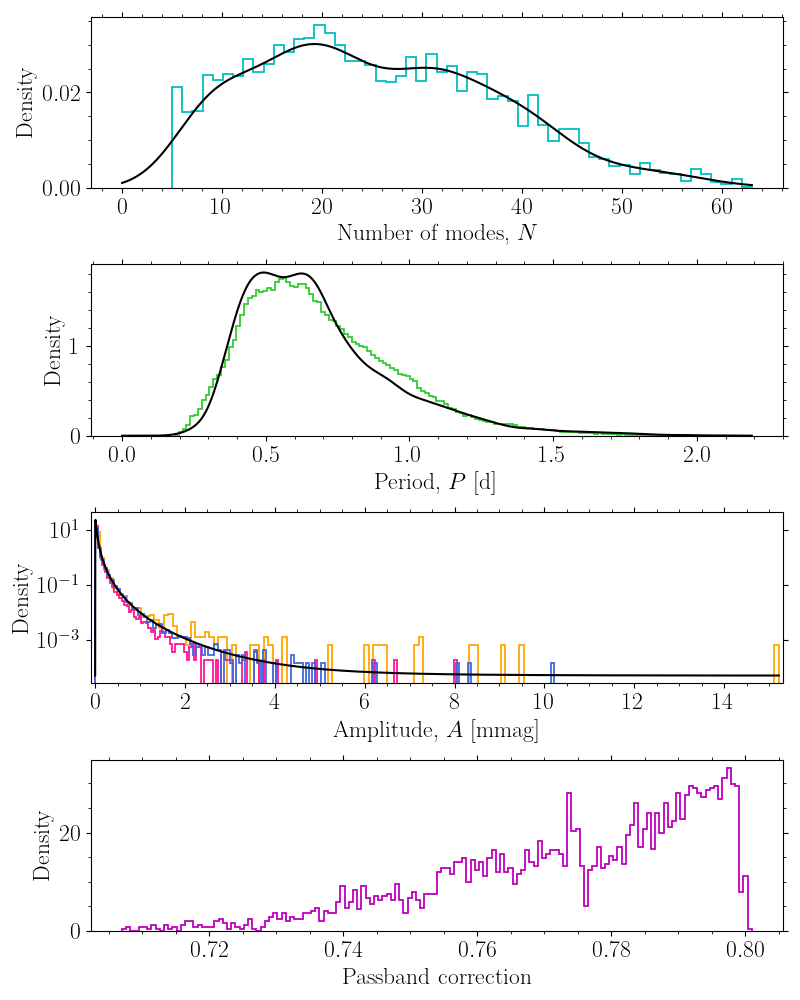

In [12]:
# Histograms
panels = 4
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_modes, bins=int(np.max(N_modes)-6), histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(1/df.freq, bins=150, histtype='step', density=True, ec='limegreen', lw=1.3)
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax[1].plot(P_range, P_kde_hist, 'k-', label='KDE')
ax[1].set_xlabel(r'Period, $P$ [d]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mag, bins=150, histtype='step', density=True, ec='orange', lw=1.3)
ax[2].hist(A_sim, bins=150, histtype='step', density=True, ec='deeppink', lw=1.3)
ax[2].hist(A_PC,  bins=150, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(A_range_mag, A_lognorm, 'k-', label='Log-norm fit')
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(-0.1, A_mag.max()+0.1)

h = ax[3].hist(PC, bins=150, histtype='step', density=True, ec='m', lw=1.3)
ax[3].set_xlabel(r'Passband correction')
ax[3].set_ylabel('Density')

# Settings
# ax[0].set_title(r'Input model for $\gamma$ Dor', pad=15)
for i in range(panels): ax[i].set_ylabel('Density')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

---
## Detection rates
---

In [37]:
files_table = natsort.natsorted(glob.glob(f'{patha}/table/*'))
files_modes = natsort.natsorted(glob.glob(f'{patha}/final/*'))

dv = pd.read_feather(files_table[0])
dv.head()

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,5610692632640232832,105.272209,-27.191568,13.964593,1,1,2,2,2633.148357,2793.087382,13.271723,-32.204427,-48.696670,3,0.000545
1,1,5610692632640232832,105.272209,-27.191568,13.964593,1,1,6,2,2633.022525,2793.323575,13.270795,-32.200176,-48.694405,3,0.001652
2,1,5610692632640232832,105.272209,-27.191568,13.964593,1,2,2,2,2619.473899,2804.645007,13.201523,-31.996390,-48.450530,3,0.000250
3,1,5610692632640232832,105.272209,-27.191568,13.964593,1,2,6,2,2619.348249,2804.881002,13.200595,-31.992142,-48.448268,3,0.000398
4,1,5610692632640232832,105.272209,-27.191568,13.964593,1,3,2,2,2628.387581,2793.603790,13.254927,-32.195132,-48.610976,3,0.000177


In [38]:
def match_modes(file_parameters, file_pulsations, file_modes, file_table):

    # Load files from for varsource
    dp = pd.read_feather(file_parameters)
    do = pd.read_feather(file_pulsations)
    
    # Load results from simulations
    dt = pd.read_feather(file_table)
    dm = pd.read_feather(file_modes)
    
    # Correct for gamma factor
    do.ampl /= 2.2

    # Convert amplitudes [dmag -> ppm]
    do.ampl = (1 - ut.fromMagToFlux(do.ampl)) * 1e6

    # Fetch input frequencies in pettern
    f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day 
                        for i in range(dp.N_modes[0])])

    # Find indices of matching frequencies
    dex_do = np.array([ut.findNearestIndex(do.freq, f_i[i]) for i in range(dp.N_modes[0])])
    dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
    
    # Get pattern passed BIC criterion
    do_bic = do.loc[dex_do].reset_index(drop=True)
    dm_bic = dm.loc[dex_dm].reset_index(drop=True)

    # Get pattern passed SNR criterion
    do_snr = do_bic[dm_bic.passed_snr].reset_index(drop=True)
    dm_snr = dm_bic[dm_bic.passed_snr].reset_index(drop=True)
    
    # Compute O-C values [ppm]
    f_oc_bic = (dm_bic.freq.to_numpy() - do_bic.freq.to_numpy())
    f_oc_snr = (dm_snr.freq.to_numpy() - do_snr.freq.to_numpy())
    A_oc_bic = (dm_bic.ampl.to_numpy() - do_bic.ampl.to_numpy())
    A_oc_snr = (dm_snr.ampl.to_numpy() - do_snr.ampl.to_numpy())

    # Remove matches above O-C threshold
    x = 0.0005
    dex_bic = np.where((np.abs(f_oc_bic) > x))[0]
    dex_snr = np.where((np.abs(f_oc_snr) > x))[0]
    dm_bic = dm_bic.drop(index=dex_bic)
    dm_snr = dm_snr.drop(index=dex_snr)
    f_oc_bic = np.delete(f_oc_bic, dex_bic) * 1e6
    f_oc_snr = np.delete(f_oc_snr, dex_snr) * 1e6
    A_oc_bic = np.delete(A_oc_bic, dex_bic)
    A_oc_snr = np.delete(A_oc_snr, dex_snr)

    # Store values into data frame
    df_oc_bic = pd.DataFrame({'freq':dm_bic.freq, 'ampl':dm_bic.ampl,
                              'freq_oc':f_oc_bic, 'ampl_oc':A_oc_bic})
    df_oc_snr = pd.DataFrame({'freq':dm_snr.freq, 'ampl':dm_snr.ampl,
                              'freq_oc':f_oc_snr, 'ampl_oc':A_oc_snr})
    
    # Store in data frame
    dx = pd.DataFrame({'Pmag': dp.Pmag,
                       'ncam': dt.shape[0],
                       'rOA': dt.rOA.mean(),
                       'SPR': dt.SPR.mean(),
                       'A_max': dm.ampl.max(),
                       'A_limit': dm_bic.ampl.min(),
                       'N_input': dp.N_modes[0],
                       'N_bic': dm_bic.shape[0],
                       'N_snr': dm_snr.shape[0],
                       'f_rms_bic': ut.rootMeanSquare(f_oc_bic),
                       'f_rms_snr': ut.rootMeanSquare(f_oc_snr),
                       'A_rms_bic': ut.rootMeanSquare(A_oc_bic),
                       'A_rms_snr': ut.rootMeanSquare(A_oc_snr),
                      })
    
    return dx, df_oc_bic, df_oc_snr 

In [39]:
def fetch_all_modes(batch='affogato'):
    
    files_parameters = natsort.natsorted(glob.glob(f'{pathv}/parameters/*'))
    files_pulsations = natsort.natsorted(glob.glob(f'{pathv}/pulsations/*'))
    files_modes = natsort.natsorted(glob.glob(f'{path}/{batch}/modes/*'))
    files_table = natsort.natsorted(glob.glob(f'{path}/{batch}/table/*'))
    
    dx = pd.DataFrame()
    df_bic = pd.DataFrame()
    df_snr = pd.DataFrame()
    for i in tqdm(range(len(files_modes)), bar_format=ut.tqdmBar()):    

        dx0, df0_bic, df0_snr = match_modes(files_parameters[i], 
                                             files_pulsations[i], 
                                             files_modes[i], 
                                             files_table[i])
        dx = pd.concat([dx, dx0])
        df_bic = pd.concat([df_bic, df0_bic])
        df_snr = pd.concat([df_snr, df0_snr])
    
    return dx, df_bic, df_snr

In [40]:
dx, df_bic, df_snr = fetch_all_modes(batch='finals_affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [01:05<00:00, 60.64it/s]          


In [41]:
dx0 = dx.sort_values(by=['ncam', 'Pmag'])
dx0.ncam.unique()

array([ 22,  24,  26,  33,  34,  36,  38,  39,  40,  42,  44,  46,  47,
        48,  55,  58,  62,  66,  70,  78,  82,  86,  91,  94,  96,  97,
        98, 100, 102, 104, 108, 110, 111, 112, 116, 118, 120, 122, 126,
       127, 128, 132, 133, 134, 136, 137, 138, 139, 140, 142, 143, 144,
       145, 146, 148, 149, 150, 152, 155, 156, 160, 162, 167, 168, 170,
       171, 176, 178, 180, 184, 186, 188, 190, 192])

<IPython.core.display.Javascript object>


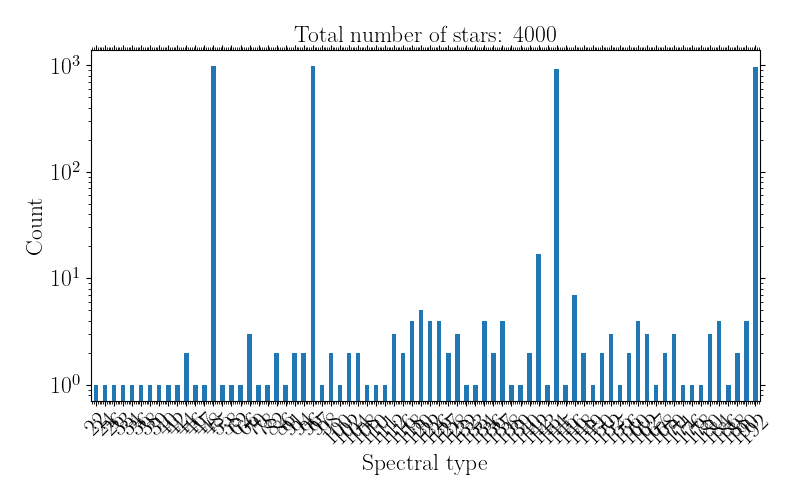

In [42]:
# Total number of stars after cuts
fig, ax = plt.subplots(1,1, figsize=(8,5))
order = dx0.ncam.unique()
dx0.ncam.value_counts().loc[order].plot.bar(rot=45)
ax.set_title(f'Total number of stars: {dx0.shape[0]}')
ax.set_xlabel('Spectral type')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Recovery of mode counts

In [43]:
N = np.max([dx.N_input.max(), dx.N_bic.max(), dx.N_snr.max()])

count_input, bin_input = np.histogram(dx.N_input, bins=N, range=(0, N))
count_bic, bin_bic     = np.histogram(dx.N_bic,   bins=N, range=(0, N))
count_snr, bin_snr     = np.histogram(dx.N_snr,   bins=N, range=(0, N))

N_oc_bic = count_bic - count_input
N_oc_snr = count_snr - count_input

<IPython.core.display.Javascript object>


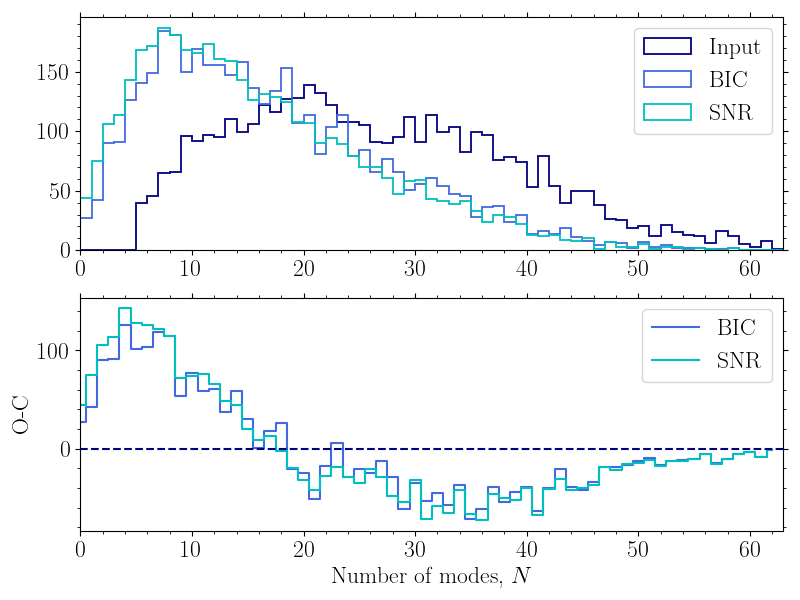

In [44]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dx.N_input, bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(dx.N_bic,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].hist(dx.N_snr,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='c', label='SNR')

ax[1].plot(range(0, N), N_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot(range(0, N), N_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
ax[1].plot([0, N], [0, 0], '--', c='navy')
ax[1].set_ylabel('O-C')
ax[1].set_xlabel(r'Number of modes, $N$')

# ax[0].set_title(r'$\gamma$ Dor', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, N)
    ax[i].legend(loc='best')
#     ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

### Recovery of mode frequencies

In [45]:
N = 150
f_max = np.max(df_bic.freq)

count_input, bin_input = np.histogram(df.freq,     bins=N, range=(0, f_max))
count_bic, bin_bic     = np.histogram(df_bic.freq, bins=N, range=(0, f_max))
count_snr, bin_snr     = np.histogram(df_snr.freq, bins=N, range=(0, f_max))

f_oc_bic = count_bic / count_input * 100
f_oc_snr = count_snr / count_input * 100

In [ ]:
# # TESTING

# fig, ax = plt.subplots(1, 1, figsize=(8, 4))
# ax.hist(df_bic.freq_oc, bins=500, histtype='step', density=False, lw=1.3, ec='navy', label='Input')
# # ax.plot(np.linspace(0, f_max, N), f_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
# # ax.plot(np.linspace(0, f_max, N), f_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
# # ax.plot([0, N], [100, 100], '--', c='navy')
# ax.set_ylabel('Recovery rate [\%]')
# ax.set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')


<IPython.core.display.Javascript object>


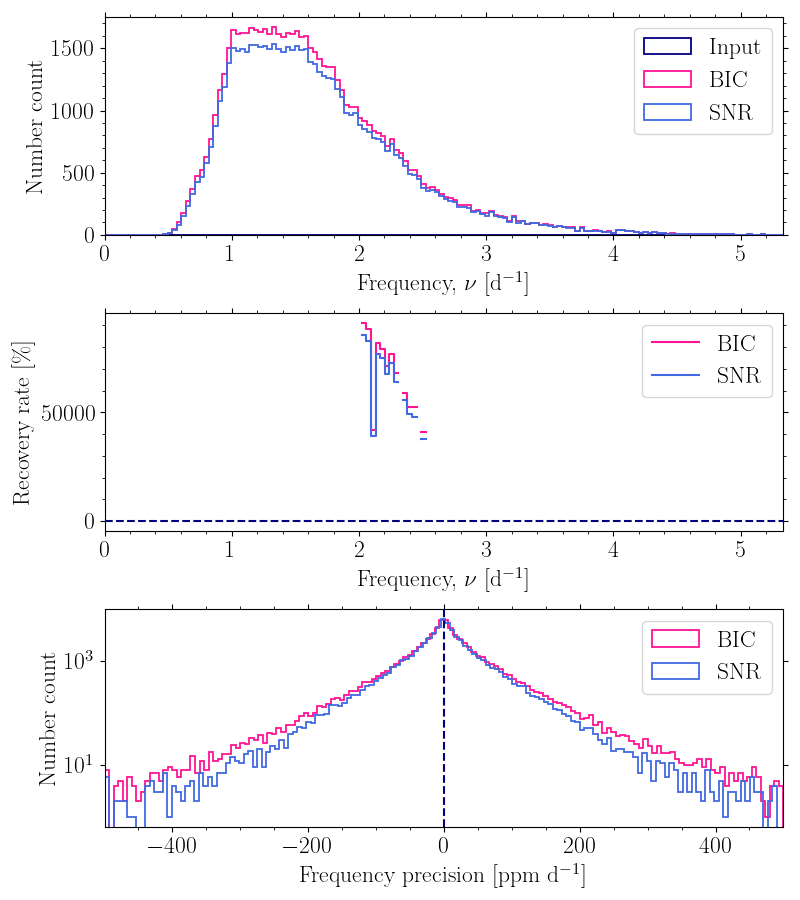

In [47]:
# FREQUENCY RECOVERY HISTOGRAMS
panels = 3
c = ['navy', 'deeppink', 'royalblue']

fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(df.freq,     bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[0], label='Input')
ax[0].hist(df_bic.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[1], label='BIC')
ax[0].hist(df_snr.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[2], label='SNR')
ax[0].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[0].set_ylabel('Number count')
ax[0].set_xlim(0, f_max)
# ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, f_max, N), f_oc_bic, '-', drawstyle='steps-mid', c=c[1], label='BIC')
ax[1].plot(np.linspace(0, f_max, N), f_oc_snr, '-', drawstyle='steps-mid', c=c[2], label='SNR')
ax[1].axhline(y=100, color=c[0], linestyle='--')
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlim(0, f_max)

ax[2].hist(df_bic.freq_oc, bins=N, histtype='step', density=False, lw=1.3, ec=c[1], label='BIC')
ax[2].hist(df_snr.freq_oc, bins=N, histtype='step', density=False, lw=1.3, ec=c[2], label='SNR')
ax[2].axvline(x=0, color=c[0], linestyle='--')
ax[2].set_xlabel(r'Frequency precision [ppm d$^{-1}$]')
ax[2].set_ylabel('Number count')
ax[2].set_xlim(df_bic.freq_oc.min(), df_bic.freq_oc.max())
ax[2].set_yscale('log')

for i in range(panels): ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

### Recovery of modes amplitudes

In [48]:
N = 150
A = df.ampl / 2.2 * 1e3
A_bic = 2.5*np.log10(df_bic.ampl / 1e6  + 1) * 1e3
A_max = np.max(A_bic)

count_input, bin_input = np.histogram(A,     bins=N, range=(0, A_max))
count_bic, bin_bic     = np.histogram(A_bic, bins=N, range=(0, A_max))

A_oc_bic = count_bic / count_input * 100

<IPython.core.display.Javascript object>


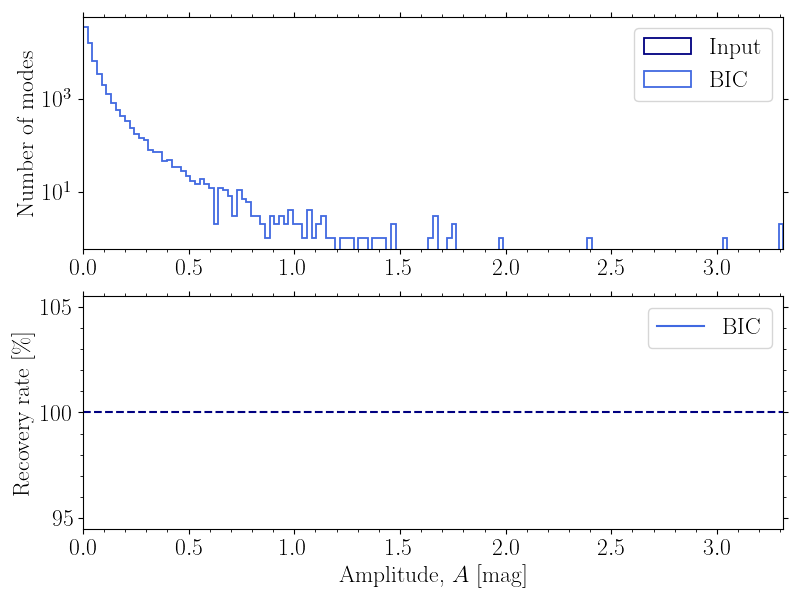

In [49]:
# AMPLITUDE RECOVERY HISTOGRAM
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(A,     bins=N, range=(0, np.max(A_max)), histtype='step', density=False, lw=1.3, ec='navy',      label='Input')
ax[0].hist(A_bic, bins=N, range=(0, A_max),         histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
# ax[0].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[0].set_ylabel('Number of modes')
ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot([0, A_max], [100, 100], '--', c='navy')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlabel(r'Amplitude, $A$ [mag]')

# ax[0].set_title(r'$\gamma$ Dor: Amplitde histogram', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, A_max)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

In [50]:
dx0 = dx.sort_values(by=['ncam', 'Pmag']).dropna()
dx0

,Pmag,ncam,rOA,SPR,A_max,A_limit,N_input,N_bic,N_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,10.839574,22,18.135953,0.008102,145.774236,12.916031,23,10,4,218.328474,60.899570,4.475229,3.685210
0,12.864400,24,19.531120,0.000000,138.925733,53.473875,18,2,1,91.992285,96.157304,14.694048,13.887847
0,11.388591,26,19.528489,0.004438,535.800704,16.544109,45,20,17,148.309143,149.000729,8.440250,9.084231
0,11.543505,33,17.726161,0.014621,174.572887,16.219026,37,11,10,47.138557,44.481903,5.276143,5.362351
0,7.958759,34,19.520870,0.000000,150.050341,2.629931,21,19,18,45.017439,45.869331,2.714709,2.770972
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,13.883281,192,10.450492,0.003204,62.711111,30.042610,34,5,4,183.378533,134.476414,8.953395,9.875671
0,13.893029,192,13.348881,0.028256,106.887466,31.130041,16,5,4,65.109824,62.504304,7.507633,8.389290
0,13.896692,192,11.596839,0.022932,91.275964,30.571979,20,6,5,180.211914,197.137997,3.675037,3.943454
0,13.943333,192,12.627131,0.030088,442.087656,45.393540,29,10,10,36.468277,36.468277,6.785150,6.785150


In [51]:
# fig, ax = plt.subplots(a, 1, figsize=(8, 6))

# ax.plot()

In [52]:
dx_na = dx.sort_values(by=['Pmag', 'ncam']).dropna()

# For plotting
dx0 = dx.sort_values('ncam')
dx1 = dx.sort_values('SPR', ascending=False)

# Calculate limits
m = 100
A_limit_med = median_filter(dx.A_limit, m)
A_rms_med   = median_filter(dx.A_rms_snr, m)
f_rms_med   = median_filter(dx.f_rms_snr, m)

dx06 = dx[dx.ncam == 48]
dx12 = dx[dx.ncam == 96]
dx18 = dx[dx.ncam == 144]
dx24 = dx[dx.ncam == 192]

A_limit_med06 = median_filter(dx06.A_limit, m)
A_limit_med12 = median_filter(dx12.A_limit, m)
A_limit_med18 = median_filter(dx18.A_limit, m)
A_limit_med24 = median_filter(dx24.A_limit, m)

A_rms_med06 = median_filter(dx06.A_rms_snr, m)
A_rms_med12 = median_filter(dx12.A_rms_snr, m)
A_rms_med18 = median_filter(dx18.A_rms_snr, m)
A_rms_med24 = median_filter(dx24.A_rms_snr, m)

<IPython.core.display.Javascript object>


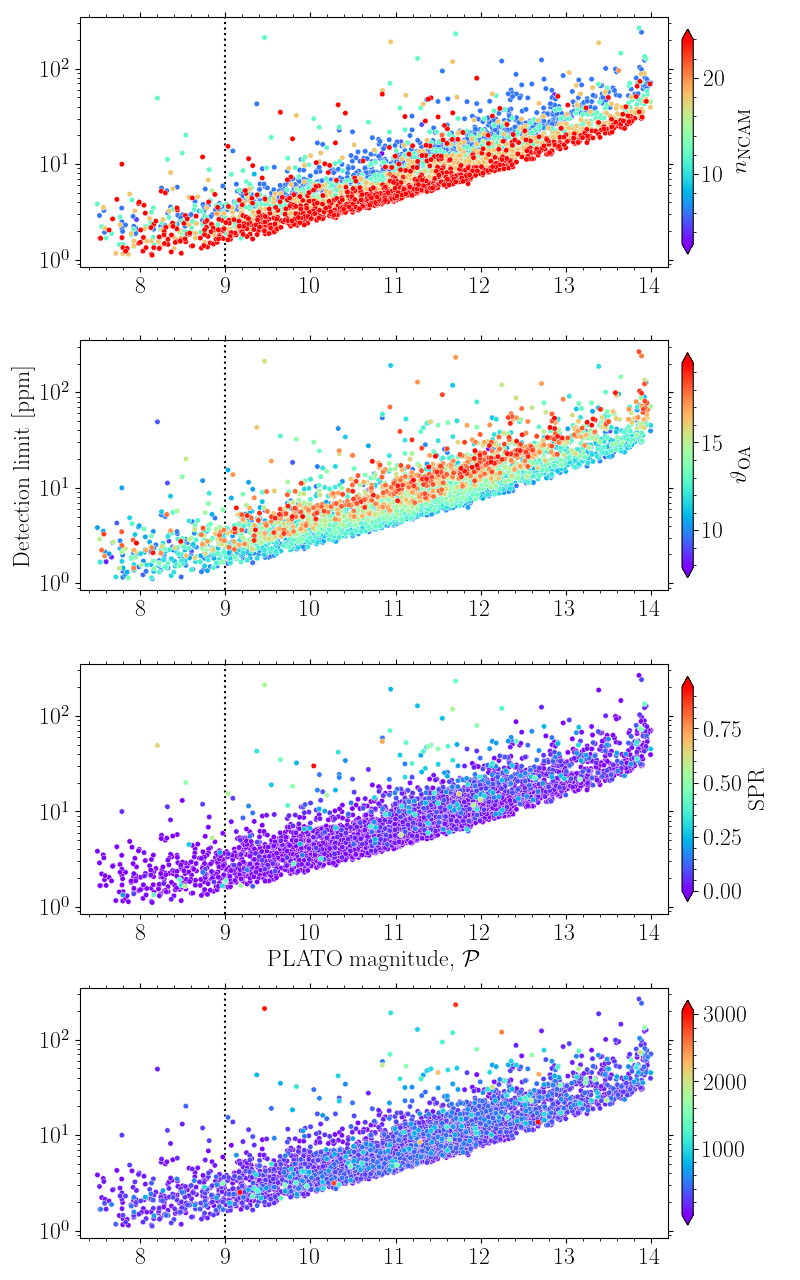

In [57]:
# Histograms
panels = 4
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('NCAM', ascending=True)
dx1 = dx.sort_values('rOA',  ascending=True)
dx2 = dx.sort_values('SPR',  ascending=True)
dx3 = dx.sort_values('A_max', ascending=True)
scat0 = ax[0].scatter(dx0.Pmag, dx0.A_limit, c=dx0['NCAM'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=1)
scat1 = ax[1].scatter(dx1.Pmag, dx1.A_limit, c=dx1['rOA'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=2)
scat2 = ax[2].scatter(dx2.Pmag, dx2.A_limit, c=dx2['SPR'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=3)
scat3 = ax[3].scatter(dx3.Pmag, dx3.A_limit, c=dx3['A_max'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap, zorder=4)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9)
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar2 = plt.colorbar(scat2, extend='both', pad=0.02, shrink=0.9)
cbar3 = plt.colorbar(scat3, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$n_{\rm NCAM}$')
cbar1.set_label(r'$\vartheta_{\rm OA}$')
cbar2.set_label('SPR')
# Settings
ax[1].set_ylabel('Detection limit [ppm]')
ax[2].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(panels):
    ax[i].axvline(x=9.0, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);

<IPython.core.display.Javascript object>


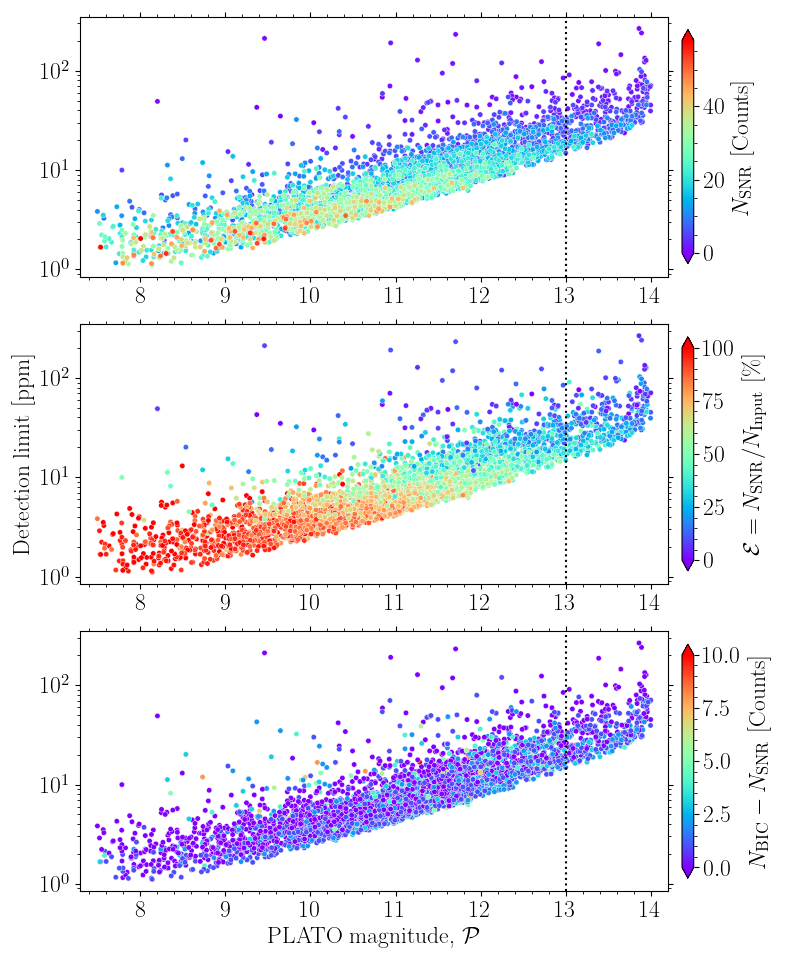

In [58]:
# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('N_snr', ascending=True)
dx1 = dx.sort_values('N_input', ascending=True)
dx2 = dx.sort_values('N_snr', ascending=False)
# dx3 = dx.sort_values('A_max', ascending=True)
scat0 = ax[0].scatter(dx0.Pmag, dx0.A_limit, c=dx0.N_snr, marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat1 = ax[1].scatter(dx1.Pmag, dx1.A_limit, c=dx1.N_snr/dx1.N_input*100,  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat2 = ax[2].scatter(dx2.Pmag, dx2.A_limit, c=dx2.N_bic-dx2.N_snr, marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
# scat3 = ax[3].scatter(dx3.Pmag, dx3.A_limit, c=dx3['A_max']/1e3, marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9)
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar2 = plt.colorbar(scat2, extend='both', pad=0.02, shrink=0.9)
# cbar3 = plt.colorbar(scat3, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$N_{\rm SNR}$ [Counts]')
cbar1.set_label(r'$\mathcal{E} = N_{\rm SNR} / N_{\rm Input}$ [\%]')
cbar2.set_label(r'$N_{\rm BIC} - N_{\rm SNR}$ [Counts]')

# cbar3.set_label(r'$A_{\rm max}$ [ppt]')
# Settings
ax[1].set_ylabel('Detection limit [ppm]')
ax[2].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(panels):
    ax[i].axvline(x=13.0, linestyle=':', color='k')
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);
# fig.savefig(f'{fdir}/detection_SPB_counts.png', bbox_inches='tight', dpi=300);

<IPython.core.display.Javascript object>


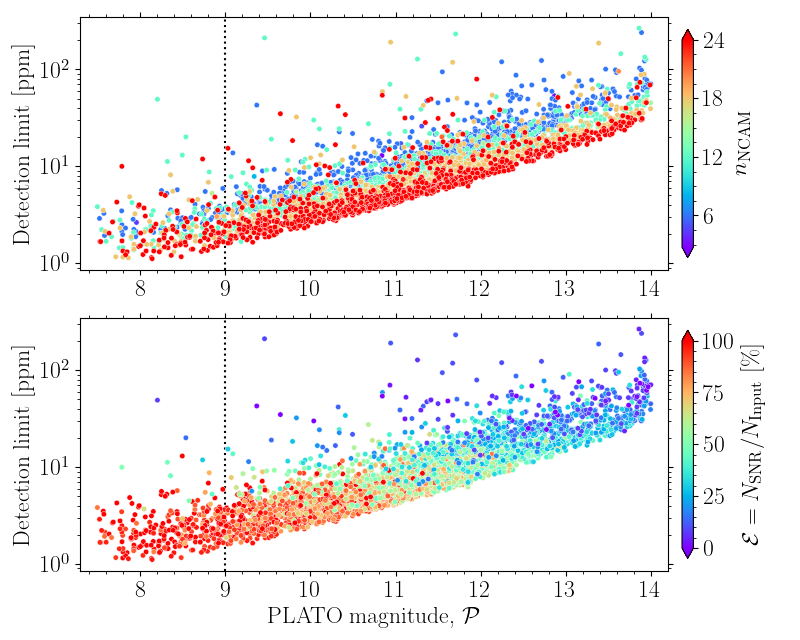

In [59]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))
cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('NCAM', ascending=True)
dx1 = dx.sort_values('N_snr', ascending=False)
scat0 = ax[0].scatter(dx0.Pmag, dx0.A_limit, c=dx0['NCAM'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat1 = ax[1].scatter(dx1.Pmag, dx1.A_limit, c=dx1.N_snr/dx1.N_input*100,  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9, ticks=[6, 12, 18, 24])
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$n_{\rm NCAM}$')
cbar1.set_label(r'$\mathcal{E} = N_{\rm SNR} / N_{\rm Input}$ [\%]')
# Settings
ax[1].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(panels):
    ax[i].set_ylabel('Detection limit [ppm]')
    ax[i].axvline(x=9.0, linestyle=':', color='k', zorder=0)
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);
fig.savefig(f'{fdir}/talk/detection_GDOR_counts.png', bbox_inches='tight', dpi=300);

<IPython.core.display.Javascript object>


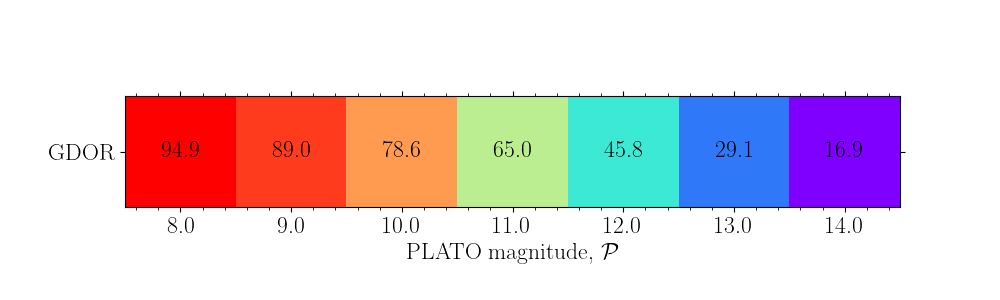

In [60]:
# Plot a detection matrix
P_bins = np.arange(7.5, 15.5, 1) 

data = [dx[dx["Pmag"].between(P_bins[i], P_bins[i+1])] for i in range(len(P_bins)-1)]
E_bins = [data[i]["N_snr"].mean()/data[i]["N_input"].mean()*100 for i in range(len(data))]

data = np.array([E_bins])
xlab = P_bins[:-1] + 0.5
ylab = ['GDOR']
# ylab = [r'$\gamma$ Dor', f'$\delta$ Sct', 'SPB', r'$\beta$ Cep']

fig, ax = plt.subplots(1, 1, figsize=(10,3))
im = ax.imshow(data, cmap='rainbow')
for i in range(len(ylab)):
    for j in range(len(xlab)):
        text = ax.text(j, i, f'{data[i, j]:.1f}', ha="center", va="center", color="k")
        
# cbar = plt.colorbar(im, extend='both', pad=0.02, shrink=0.9, orientation='horizontal')
# cbar.set_label('Detection efficiency [\%]')
ax.set_xlabel('PLATO magnitude, $\mathcal{P}$')

ax.set_xticks(np.arange(len(xlab)), labels=xlab)
ax.set_yticks(np.arange(len(ylab)), labels=ylab)
# ax.set_title('Affogato');

# fig.savefig(f'{fdir}/talk/detection_SPB_efficiency.png', bbox_inches='tight', dpi=300);

### Amplitude precision

In [ ]:
# Histograms
panels = 4
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('NCAM',  ascending=True)
dx1 = dx.sort_values('rOA',   ascending=True)
dx2 = dx.sort_values('SPR',   ascending=True)
dx3 = dx.sort_values('A_max', ascending=True)
scat0 = ax[0].scatter(dx0.Pmag, dx0.A_rms_snr, c=dx0['NCAM'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat1 = ax[1].scatter(dx1.Pmag, dx1.A_rms_snr, c=dx1['rOA'],   marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat2 = ax[2].scatter(dx2.Pmag, dx2.A_rms_snr, c=dx2['SPR'],   marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat3 = ax[3].scatter(dx3.Pmag, dx3.A_rms_snr, c=dx3['A_max'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9)
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar2 = plt.colorbar(scat2, extend='both', pad=0.02, shrink=0.9)
cbar3 = plt.colorbar(scat3, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$n_{\rm NCAM}$')
cbar1.set_label(r'$\vartheta_{\rm OA}$')
cbar2.set_label('SPR')
cbar3.set_label(r'$A_{\rm max}$')
# Settings
ax[1].set_ylabel('Amplitude precision [ppm]')
ax[2].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(panels):
    ax[i].axvline(x=13.0, linestyle=':', color='k')
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);

In [ ]:
# Histograms
panels = 4
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('NCAM',  ascending=True)
dx1 = dx.sort_values('rOA',   ascending=True)
dx2 = dx.sort_values('SPR',   ascending=True)
dx3 = dx.sort_values('A_max', ascending=True)
scat0 = ax[0].scatter(dx0.Pmag, dx0.f_rms_snr, c=dx0['NCAM'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat1 = ax[1].scatter(dx1.Pmag, dx1.f_rms_snr, c=dx1['rOA'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat2 = ax[2].scatter(dx2.Pmag, dx2.f_rms_snr, c=dx2['SPR'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat3 = ax[3].scatter(dx3.Pmag, dx3.f_rms_snr, c=dx3['A_max'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9)
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar2 = plt.colorbar(scat2, extend='both', pad=0.02, shrink=0.9)
cbar3 = plt.colorbar(scat3, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$n_{\rm NCAM}$')
cbar1.set_label(r'$\vartheta_{\rm OA}$')
cbar2.set_label('SPR')
cbar3.set_label(r'$A_{\rm max}$')
# Settings
ax[1].set_ylabel('Frequency precision [ppm/d]')
ax[2].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(4):
    ax[i].axvline(x=13.0, linestyle=':', color='k')
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);

In [ ]:
# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 3.2*panels))

cmap = 'rainbow'
dx['NCAM'] = dx.ncam / 8
dx0 = dx.sort_values('A_max', ascending=True)
dx1 = dx.sort_values('rOA',  ascending=True)
dx2 = dx.sort_values('SPR',  ascending=True)
scat0 = ax[0].scatter(dx0.Pmag, dx0.A_rms_snr, c=dx0['A_max'], marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat1 = ax[1].scatter(dx1.Pmag, dx1.A_rms_snr, c=dx1['rOA'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
scat2 = ax[2].scatter(dx2.Pmag, dx2.A_rms_snr, c=dx2['SPR'],  marker='o', s=15, lw=0.3, edgecolor='w', cmap=cmap)
cbar0 = plt.colorbar(scat0, extend='both', pad=0.02, shrink=0.9)
cbar1 = plt.colorbar(scat1, extend='both', pad=0.02, shrink=0.9)
cbar2 = plt.colorbar(scat2, extend='both', pad=0.02, shrink=0.9)
cbar0.set_label(r'$n_{\rm NCAM}$')
cbar1.set_label(r'$\vartheta_{\rm OA}$')
cbar2.set_label('SPR')
# Settings
ax[1].set_ylabel('Detection limit [ppm]')
ax[2].set_xlabel('PLATO magnitude, $\mathcal{P}$')
for i in range(3):
    ax[i].axvline(x=13.0, linestyle=':', color='k')
    ax[i].set_xlim(dx.Pmag.min()-0.2, dx.Pmag.max()+0.2)
    ax[i].set_yscale('log')
plt.tight_layout(pad=0.5);

In [53]:

# # Histograms
# panels = 3
# fig, ax = plt.subplots(panels, 1, figsize=(8, 5*panels))

# ax[0].scatter(dx.Pmag, dx.A_limit, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# # ax[0].plot(dx.Pmag, A_limit_med, '-', c='navy',   lw=1.0)
# ax[0].plot(dx06.Pmag, A_limit_med06, ':',  lw=2.0, c='r')
# ax[0].plot(dx12.Pmag, A_limit_med12, '-.', lw=2.0, c='tomato')
# ax[0].plot(dx18.Pmag, A_limit_med18, '--', lw=2.0, c='orange')
# ax[0].plot(dx24.Pmag, A_limit_med24, '-',  lw=2.0, c='gold')
# ax[0].set_ylabel('Detection limit [ppm]')
# ax[0].set_ylim(0, 200)
# # cmap="viridis"

# ax[1].scatter(dx.Pmag, dx.A_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# # ax[1].plot(dx.Pmag, dx.A_rms_snr, '.', c='orange', ms=2, mec='gray', lw=1)
# ax[1].plot(dx.Pmag, A_rms_med, '-', c='navy',   lw=1.0)
# ax[1].set_ylabel('Amplitude RMS [ppm]')
# ax[1].set_ylim(0, 2000)

# ax[2].scatter(dx.Pmag, dx.f_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# ax[2].plot(dx.Pmag, f_rms_med, '-', c='navy', lw=1.0)
# ax[2].set_ylabel('Frequency RMS [ppm/d]')
# ax[2].set_xlabel(r'PLATO magnitude, $P$')

# # ax[0].set_yscale('log')

# # ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
# # ax[1].plot([0, A_max], [100, 100], '--', c='navy')
# # ax[1].set_ylabel('Recovery rate [\%]')
# # ax[1].set_xlabel(r'Amplitude, $A$ [ppm]')

# ax[0].set_title(r'$\gamma$ Dor: Noise limits', pad=15)
# for i in range(panels): 
#     ax[i].set_xlim(dx.Pmag.min(), dx.Pmag.max())
# #     ax[i].legend(loc='best')
# plt.tight_layout(pad=0.5);